In [62]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

In [2]:
df1=pd.read_csv("iplauction2023.csv")
df1.shape

(309, 7)

<h2 style='font:32 color:black'>Data Understanding</h2>

In [3]:
df1.head()

,name,player style,nationality,base price (in lacs),final price (in lacs),franchise,status
0,Harshit Rana,Bowler,India,NaN,20.0,KKR,RETAINED
1,Ekant Sen,Batter,India,20.0,NaN,NaN,UNSOLD
2,Wayne Parnell,Allrounder,South Africa,75.0,NaN,NaN,UNSOLD
3,Shakib Al Hasan,Allrounder,Bangladesh,150.0,150.0,KKR,SOLD
4,Joe Root,Batter,England,100.0,100.0,RR,SOLD


In [4]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 309 entries, 0 to 308
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   name                   309 non-null    object 
 1   player style           309 non-null    object 
 2   nationality            309 non-null    object 
 3   base price (in lacs)   151 non-null    float64
 4   final price (in lacs)  238 non-null    float64
 5   franchise              238 non-null    object 
 6   status                 309 non-null    object 
dtypes: float64(2), object(5)
memory usage: 17.0+ KB


In [5]:
#lets check for duplicated players
df1[df1.duplicated(subset=['name','player style'])]

,name,player style,nationality,base price (in lacs),final price (in lacs),franchise,status


In [8]:
df1.dtypes

name                      object
player style              object
nationality               object
base price (in lacs)     float64
final price (in lacs)    float64
franchise                 object
status                    object
dtype: object

<h2 style='font:32 color:black'>Data Preprocessing</h2>

In [9]:
df2=df1.copy()
df2.head()

,name,player style,nationality,base price (in lacs),final price (in lacs),franchise,status
0,Harshit Rana,Bowler,India,NaN,20.0,KKR,RETAINED
1,Ekant Sen,Batter,India,20.0,NaN,NaN,UNSOLD
2,Wayne Parnell,Allrounder,South Africa,75.0,NaN,NaN,UNSOLD
3,Shakib Al Hasan,Allrounder,Bangladesh,150.0,150.0,KKR,SOLD
4,Joe Root,Batter,England,100.0,100.0,RR,SOLD


In [14]:
df2['base price (in lacs)'] = df2.apply(
    lambda x: x['final price (in lacs)'] if pd.isnull(x['base price (in lacs)']) else x['base price (in lacs)'],
    axis=1
)
df2.head()

,name,player style,nationality,base price (in lacs),final price (in lacs),franchise,status
0,Harshit Rana,Bowler,India,20.0,20.0,KKR,RETAINED
1,Ekant Sen,Batter,India,20.0,NaN,NaN,UNSOLD
2,Wayne Parnell,Allrounder,South Africa,75.0,NaN,NaN,UNSOLD
3,Shakib Al Hasan,Allrounder,Bangladesh,150.0,150.0,KKR,SOLD
4,Joe Root,Batter,England,100.0,100.0,RR,SOLD


In [15]:
df2['final price (in lacs)']= df2.apply(
    lambda x: x['base price (in lacs)'] if pd.isnull(x['final price (in lacs)']) else x['final price (in lacs)'],
    axis=1
)
df2.head()

,name,player style,nationality,base price (in lacs),final price (in lacs),franchise,status
0,Harshit Rana,Bowler,India,20.0,20.0,KKR,RETAINED
1,Ekant Sen,Batter,India,20.0,20.0,NaN,UNSOLD
2,Wayne Parnell,Allrounder,South Africa,75.0,75.0,NaN,UNSOLD
3,Shakib Al Hasan,Allrounder,Bangladesh,150.0,150.0,KKR,SOLD
4,Joe Root,Batter,England,100.0,100.0,RR,SOLD


In [16]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 309 entries, 0 to 308
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   name                   309 non-null    object 
 1   player style           309 non-null    object 
 2   nationality            309 non-null    object 
 3   base price (in lacs)   309 non-null    float64
 4   final price (in lacs)  309 non-null    float64
 5   franchise              238 non-null    object 
 6   status                 309 non-null    object 
dtypes: float64(2), object(5)
memory usage: 17.0+ KB


In [30]:
modal_franchise_region=df2[['nationality','franchise']].value_counts().reset_index()
modal_franchise_region.head()

,nationality,franchise,count
0,India,LSG,17
1,India,GT,17
2,India,CSK,17
3,India,SRH,17
4,India,RR,17


In [114]:
modal_franchise_region=modal_franchise_region.groupby("nationality").head(1)
modal_franchise_region=modal_franchise_region.set_index("nationality")
modal_franchise_region.head()

KeyError: "None of ['nationality'] are in the columns"

In [46]:
modal_franchise_region=modal_franchise_region.drop(columns='count')

In [47]:
modal_franchise_region.head()

,franchise
nationality,
India,LSG
South Africa,MI
New Zealand,CSK
England,RCB
West Indies,LSG


In [53]:
modal_franchise_region.loc['India','franchise']

'LSG'

In [55]:
df2['franchise'] = df2.apply(
    lambda x: modal_franchise_region.loc[x['nationality'], 'franchise']
    if pd.isnull(x['franchise']) and x['nationality'] in modal_franchise_region.index
    else x['franchise'],
    axis=1
)
df2.head()

,name,player style,nationality,base price (in lacs),final price (in lacs),franchise,status
0,Harshit Rana,Bowler,India,20.0,20.0,KKR,RETAINED
1,Ekant Sen,Batter,India,20.0,20.0,LSG,UNSOLD
2,Wayne Parnell,Allrounder,South Africa,75.0,75.0,MI,UNSOLD
3,Shakib Al Hasan,Allrounder,Bangladesh,150.0,150.0,KKR,SOLD
4,Joe Root,Batter,England,100.0,100.0,RR,SOLD


In [57]:
df2.info()
df2.describe() #used this to check for min so i can know if there is a negative number

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 309 entries, 0 to 308
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   name                   309 non-null    object 
 1   player style           309 non-null    object 
 2   nationality            309 non-null    object 
 3   base price (in lacs)   309 non-null    float64
 4   final price (in lacs)  309 non-null    float64
 5   franchise              308 non-null    object 
 6   status                 309 non-null    object 
dtypes: float64(2), object(5)
memory usage: 17.0+ KB


,base price (in lacs),final price (in lacs)
count,309.000000,309.000000
mean,258.381877,296.278317
std,378.208958,416.263606
min,20.000000,20.000000
25%,20.000000,20.000000
50%,50.000000,75.000000
75%,300.000000,400.000000
max,1700.000000,1850.000000


In [58]:
df2.dropna(subset='franchise',inplace=True)

In [59]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 308 entries, 0 to 308
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   name                   308 non-null    object 
 1   player style           308 non-null    object 
 2   nationality            308 non-null    object 
 3   base price (in lacs)   308 non-null    float64
 4   final price (in lacs)  308 non-null    float64
 5   franchise              308 non-null    object 
 6   status                 308 non-null    object 
dtypes: float64(2), object(5)
memory usage: 19.2+ KB


<h2 style='font:30 color:black'>Features Understanding</h2>

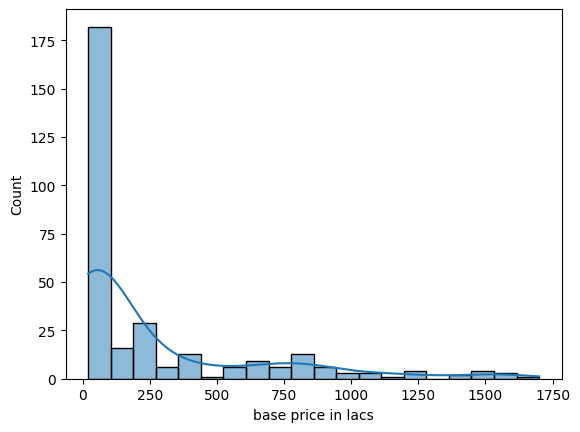

In [69]:
#distribution of price
sns.histplot(data=df2,x='base price (in lacs)',kde=True)
plt.xlabel("base price in lacs")
plt.show()

In [71]:
top5_nations=df2.groupby('nationality')['base price (in lacs)'].mean()

In [75]:
top5_nations.sort_values(ascending=False,inplace=True)
top5_nations=top5_nations.head()

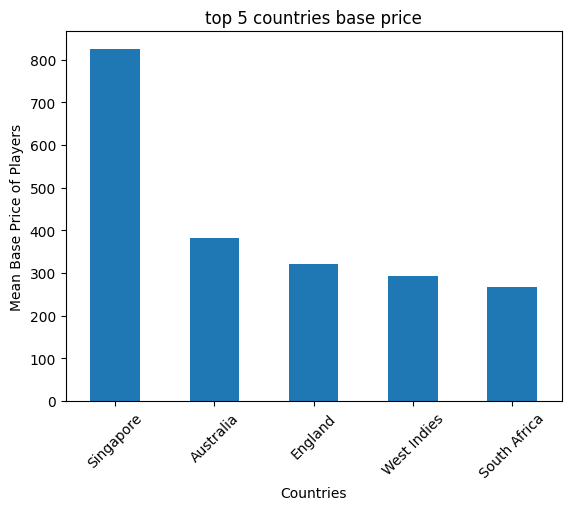

In [78]:
top5_nations.plot(kind='bar',title='top 5 countries base price')
plt.xlabel('Countries')
plt.ylabel('Mean Base Price of Players')
plt.xticks(rotation=45)
plt.show()

In [85]:
top5_franchise=df2.groupby('franchise')['base price (in lacs)'].mean()
total=top5_franchise.sum().round(2)
total

np.float64(2810.2)

In [86]:
top5_franchise.sort_values(ascending=False,inplace=True)
top5_franchise=top5_franchise.head()

In [88]:
percentage=(top5_franchise/total)*100
percentage

franchise
RR     12.468863
DC     11.498292
KKR    11.298128
MI     10.892859
RCB    10.460842
Name: base price (in lacs), dtype: float64

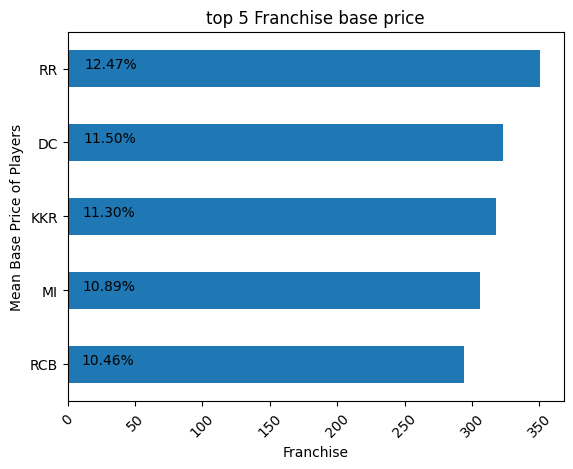

In [89]:
ax=top5_franchise.plot(kind='barh',title='top 5 Franchise base price')
plt.xlabel('Franchise')
plt.ylabel('Mean Base Price of Players')
plt.xticks(rotation=45)
for index, value in enumerate(percentage):
    ax.text(value, index, f'{value:.2f}%')
plt.gca().invert_yaxis() #to show the highest sales at the top
plt.show()

In [90]:
df2[df2.franchise=='RR']


,name,player style,nationality,base price (in lacs),final price (in lacs),franchise,status
4,Joe Root,Batter,England,100.0,100.0,RR,SOLD
5,Abdul Basith,Allrounder,India,20.0,20.0,RR,SOLD
14,Akash Vashist,Allrounder,India,20.0,20.0,RR,SOLD
19,Murugan Ashwin,Bowler,India,20.0,20.0,RR,SOLD
20,KM Asif,Bowler,India,30.0,30.0,RR,SOLD
23,Adam Zampa,Bowler,Australia,150.0,150.0,RR,SOLD
38,Kunal Singh Rathore,WK-Batter,India,20.0,20.0,RR,SOLD
70,Donavon Ferreira,WK-Batter,South Africa,20.0,50.0,RR,SOLD
132,Jason Holder,Allrounder,West Indies,200.0,575.0,RR,SOLD
165,Dhruv Jurel,WK-Batter,India,20.0,20.0,RR,RETAINED


In [115]:
#sort by mean price of each player style and the percentage of them sold
player_style_status = df2.groupby('player style').agg({
    'base price (in lacs)': 'mean',
    'status': lambda x: ((x == 'SOLD').sum() / len(x) * 100).round(2)
    #'status':'count'
}).reset_index()

player_style_status.columns = ['player style', 'mean_price', 'percent_sold']
player_style_status = player_style_status.sort_values(by='mean_price', ascending=False)
player_style_status

,player style,mean_price,percent_sold
3,WK-Batter,326.750000,27.50
1,Batter,307.545455,21.82
0,Allrounder,241.796117,31.07
2,Bowler,226.636364,22.73


inference:Allrounder sold 31% of players they auctioned

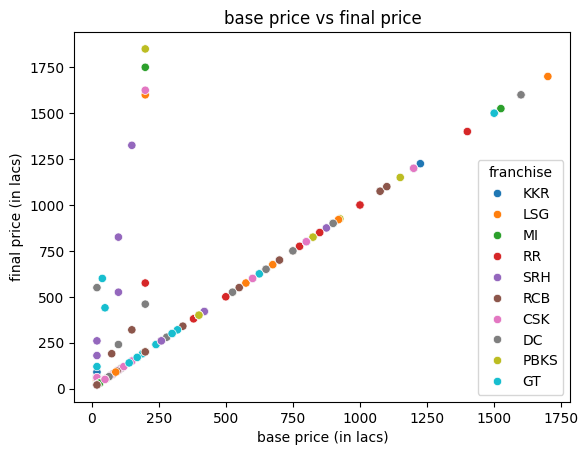

In [117]:
#lets see if there is a positive relationship between base price and sales price
sns.scatterplot(data=df2,x='base price (in lacs)',y='final price (in lacs)',
                hue='franchise'
               )
plt.title("base price vs final price")
plt.show()